<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/ADA_Lab_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Act as a data scientist given only this one-line instruction: **Predict the canada per capita income for the next 5 years, starting 2024.**

Perform the necessary steps you think you must perform.

[dataset link](https://www.kaggle.com/datasets/gurdit559/canada-per-capita-income-single-variable-data-set)


**required:**
*  initialize the model (Linear Regression)
*  make predictions from the model

**optional but recommended:**

*  split the data
*  model evaluation





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

For this assignment:
pandas handles the dataset

matplotlib gives us visualization.

LinearRegression is the required machine-learning model.

The metrics let us evaluate how well the model performs.

In [3]:
df = pd.read_csv('/content/canada_per_capita_income.csv')

df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [5]:
df.describe()

,year,per capita income (US$)
count,47.000000,47.000000
mean,1993.000000,18920.137063
std,13.711309,12034.679438
min,1970.000000,3399.299037
25%,1981.500000,9526.914515
50%,1993.000000,16426.725480
75%,2004.500000,27458.601420
max,2016.000000,42676.468370


In [6]:
df.isnull().sum()

,0
year,0
per capita income (US$),0


There are no missing values. This is GOOD! I don't need to drop any or fill with the mean.

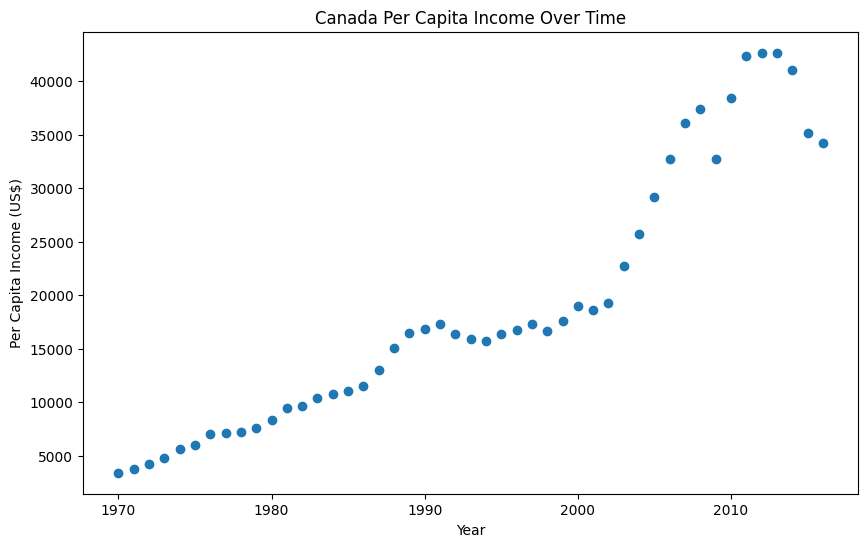

In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['year'],
    df['per capita income (US$)']
)

plt.xlabel('Year')
plt.ylabel('Per Capita Income (US$)')
plt.title('Canada Per Capita Income Over Time')

plt.show()

This is nice. There is a strong upward long-term trend, yet the relationship is clearly not perfectly linear.

So lets split the data into what is manipulated and what is measured.

In [8]:
X = df[['year']]
y = df['per capita income (US$)']

There are double brackets around year because Scikit-learn expects X to be two-dimensional.

Note on the split the data portion.

There is an important wrinkle here: this is time-series-like data.

Therefore, it would not randomly shuffle the years.

So for this, let's use the earlier observations for training and the later observations for testing.

In [9]:
# Now we actually SPLIT the data.

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

Ideally this will produce 37 training observations and 10 testing observations.

With a test period of approximately 2007-2016

In [10]:
# Now let's initialize the Linear Regression model

model = LinearRegression()

# Now let's train the model

model.fit(X_train, y_train)

LinearRegression()

The model is estimating a relationship conceptually equivalent to:

Per Capita Income =

Intercept + Slope x Year

In [11]:
# Now we'll make the predictions on the test set

y_pred = model.predict(X_test)

In [12]:
results = pd.DataFrame({
    'Year': X_test['year'],
    'Actual': y_test,
    'Predicted': y_pred
})

results

,Year,Actual,Predicted
37,2007,36144.48122,25407.236531
38,2008,37446.48609,26024.176343
39,2009,32755.17682,26641.116156
40,2010,38420.52289,27258.055969
41,2011,42334.71121,27874.995782
42,2012,42665.25597,28491.935595
43,2013,42676.46837,29108.875408
44,2014,41039.89360,29725.815220
45,2015,35175.18898,30342.755033
46,2016,34229.19363,30959.694846


In [13]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 10105.272189623778
MSE: 116383635.82617883
RMSE: 10788.124759483404
R2: -8.350800286581592


In [14]:
final_model  = LinearRegression()

final_model.fit(X, y)

LinearRegression()

In [15]:
# Let's create the future years

future_years = pd.DataFrame({
    'year': [2024, 2025, 2026, 2027, 2028]
})

In [16]:
future_predictions = final_model.predict(future_years)

In [17]:
forecast = pd.DataFrame({
    'Year': future_years['year'],
    'Predicted Per Capita Income (US$)': future_predictions
})

forecast

,Year,Predicted Per Capita Income (US$)
0,2024,44602.554395
1,2025,45431.019471
2,2026,46259.484546
3,2027,47087.949621
4,2028,47916.414696


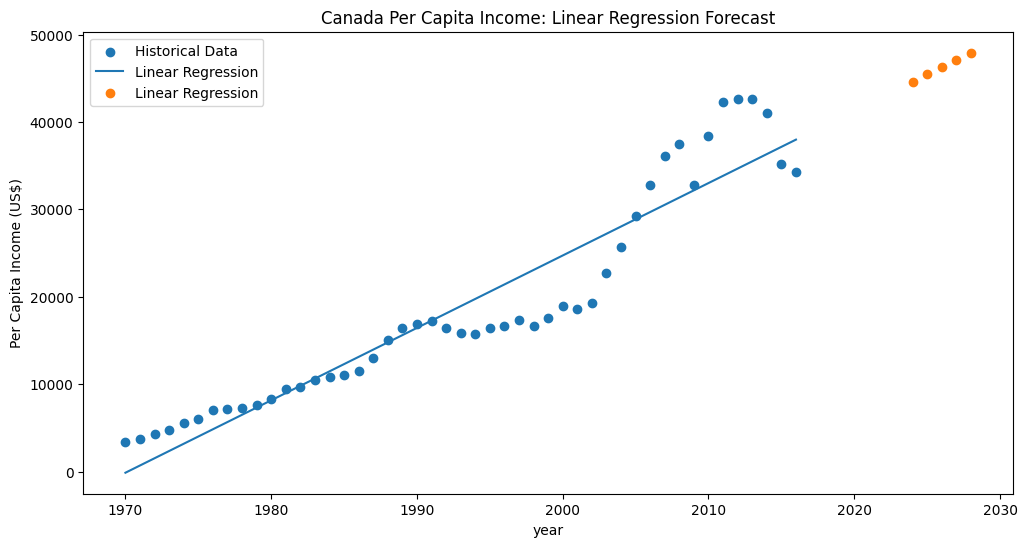

In [18]:
# Now let's plot the regression line and forecast

plt.figure(figsize=(12, 6))

plt.scatter(
    df['year'],
    df['per capita income (US$)'],
    label='Historical Data'
)

plt.plot(
    df['year'],
    final_model.predict(X),
    label='Linear Regression'
)

plt.scatter(
    future_years['year'],
    future_predictions,
    label='Linear Regression'
)

plt.xlabel('year')
plt.ylabel('Per Capita Income (US$)')
plt.title('Canada Per Capita Income: Linear Regression Forecast')
plt.legend()

plt.show()

Now let's consolidate this.

   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes
None
year                       0
per capita income (US$)    0
dtype: int64

Model Evaluation
----------------
MAE: 10105.272189623778
RMSE: 10788.124759483404
R²: -8.350800286581592

2024–2028 Forecast
------------------
   Year  Predicted Per Capita Income (US$)
0  2024                       44602.554395
1  2025                       45431.019471
2  2026                       46259.484546
3  2027                       47087

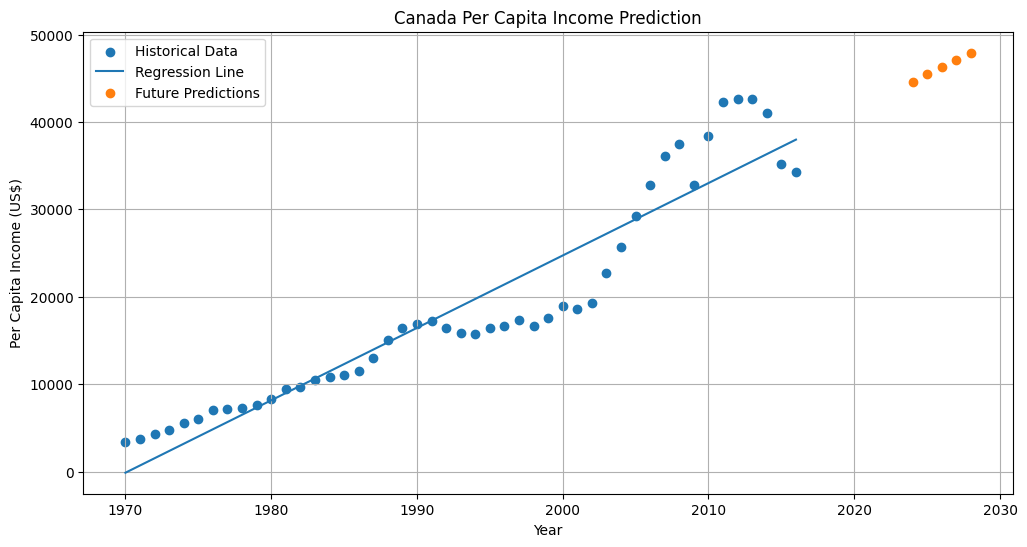

In [19]:
# ==========================================
# Canada Per Capita Income Prediction
# Linear Regression
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------

df = pd.read_csv('/content/canada_per_capita_income.csv')

print(df.head())
print(df.info())
print(df.isnull().sum())


# ------------------------------------------
# 2. Define X and y
# ------------------------------------------

X = df[['year']]
y = df['per capita income (US$)']


# ------------------------------------------
# 3. Chronological Train/Test Split
# ------------------------------------------

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


# ------------------------------------------
# 4. Initialize Linear Regression Model
# ------------------------------------------

model = LinearRegression()


# ------------------------------------------
# 5. Train Model
# ------------------------------------------

model.fit(X_train, y_train)


# ------------------------------------------
# 6. Make Test Predictions
# ------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------
# 7. Evaluate Model
# ------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


# ------------------------------------------
# 8. Train Final Model Using All Data
# ------------------------------------------

final_model = LinearRegression()

final_model.fit(X, y)


# ------------------------------------------
# 9. Predict 2024–2028
# ------------------------------------------

future_years = pd.DataFrame({
    'year': [2024, 2025, 2026, 2027, 2028]
})

future_predictions = final_model.predict(future_years)


forecast = pd.DataFrame({
    'Year': future_years['year'],
    'Predicted Per Capita Income (US$)': future_predictions
})


print("\n2024–2028 Forecast")
print("------------------")
print(forecast)


# ------------------------------------------
# 10. Visualize Results
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.scatter(
    df['year'],
    y,
    label='Historical Data'
)

plt.plot(
    df['year'],
    final_model.predict(X),
    label='Regression Line'
)

plt.scatter(
    future_years['year'],
    future_predictions,
    label='Future Predictions'
)

plt.xlabel('Year')
plt.ylabel('Per Capita Income (US$)')
plt.title('Canada Per Capita Income Prediction')
plt.legend()
plt.grid()

plt.show()

A Linear Regression model was developed using historical Canadian per-capita-income data from 1970 through 2016. Year was used as the independent variable and per-capita income as the dependent varaible. A chronological train/test split was used to evaluae the model before retraining it on the complete dataset. The final model predicts Canadian per-capita income of approximately $44,602.55 in 2024, $45,431.02 in 2025, $46,259.48 in 2026, $47,087.95 in 2027, and $47,916.41 in 2028. Although the overall historical data exhibit a strong upward linear trend, holdout evaluation demonstrates that a simple linear regression does not adequately represent all economic fluctions. Therefore, these predictions should be interpreted as trend-based estimates rather than precise economic forecasts.